<a href="https://colab.research.google.com/github/devwoo41/SilJaEon/blob/master/W5_PracticalNLP_202401569_%EC%9D%B4%EC%9A%B0%EC%A3%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Apr  1 05:14:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install datasets

from datasets import load_dataset
data = load_dataset('sp1786/multiclass-sentiment-analysis-dataset')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train_df.csv: 0.00B [00:00, ?B/s]

val_df.csv: 0.00B [00:00, ?B/s]

test_df.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [3]:
print('Data type: ', type(data))
print('Data structure: ',data)
print('Data keys: ', data.keys())

print(data['train'][0])


Data type:  <class 'datasets.dataset_dict.DatasetDict'>
Data structure:  DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 31232
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5205
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5206
    })
})
Data keys:  dict_keys(['train', 'validation', 'test'])
{'id': 9536, 'text': 'Cooking microwave pizzas, yummy', 'label': 2, 'sentiment': 'positive'}


In [4]:
def remove_empty_data(row):
  return all(row[field] not in [None,""] for field in ['id', 'text', 'label', 'sentiment'])

train_data = data['train'].filter(remove_empty_data)
dev_data = data['validation'].filter(remove_empty_data)
test_data = data['test'].filter(remove_empty_data)

print(train_data)
print(test_data)
print(train_data[0])
print(test_data[0])

Filter:   0%|          | 0/31232 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5205 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5206 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'text', 'label', 'sentiment'],
    num_rows: 31232
})
Dataset({
    features: ['id', 'text', 'label', 'sentiment'],
    num_rows: 5205
})
{'id': 9536, 'text': 'Cooking microwave pizzas, yummy', 'label': 2, 'sentiment': 'positive'}
{'id': 9235, 'text': 'getting cds ready for tour', 'label': 1, 'sentiment': 'neutral'}


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(train_data['text'])

print(vectorizer.vocabulary_)
print(len(vectorizer.vocabulary_))

train_vectors = vectorizer.transform(train_data['text'])
dev_vectors = vectorizer.transform(dev_data['text'])
test_vectors = vectorizer.transform(test_data['text'])

print(train_vectors[0])

{'cooking': 6972, 'microwave': 16372, 'pizzas': 19252, 'yummy': 28348, 'any': 3060, 'plans': 19285, 'of': 17948, 'allowing': 2730, 'sub': 24072, 'tasks': 24716, 'to': 25400, 'show': 22610, 'up': 26512, 'in': 13235, 'the': 25021, 'widget': 27580, 'love': 15482, 'humor': 12909, 'just': 14226, 'reworded': 21273, 'it': 13780, 'like': 15134, 'saying': 21914, 'group': 11822, 'therapy': 25056, 'instead': 13501, 'gang': 11131, 'banging': 3907, 'keeps': 14355, 'my': 17123, 'moms': 16724, 'off': 17953, 'back': 3765, 'hahaha': 12033, 'naw': 17281, 'idk': 13061, 'what': 27426, 'ur': 26561, 'talkin': 24646, 'about': 2151, 'that': 25006, 'sucks': 24156, 'hear': 12338, 'hate': 12237, 'days': 7722, 'umm': 26238, 'yeah': 28161, 'probably': 19893, 'pretty': 19812, 'good': 11528, 'note': 17691, 'self': 22197, 'because': 4134, 'eeeeeewwwwwwww': 9145, 'whatever': 27433, 'do': 8551, 'you': 28284, 'mean': 16114, 'would': 27888, 'panic': 18614, 'me': 16104, 'little': 15233, 'maybe': 16051, 'can': 5480, 'read'

In [6]:
sample_num = 17
sample_origin = train_data[sample_num]
sample_transform = train_vectors[sample_num]
sample_inverse_transform = vectorizer.inverse_transform(sample_transform)

print("Original Input: {}\nTransformed: {}\nInv-transformed: {}".format(sample_origin, sample_transform, sample_inverse_transform))

Original Input: {'id': 23219, 'text': 'Ok so I`m **** hungry....!  I`m fat I know..I know..! Aha', 'label': 0, 'sentiment': 'negative'}
Transformed: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 29053)>
  Coords	Values
  (0, 2551)	1
  (0, 10073)	1
  (0, 12922)	1
  (0, 14561)	2
  (0, 18020)	1
  (0, 23180)	1
Inv-transformed: [array(['aha', 'fat', 'hungry', 'know', 'ok', 'so'], dtype='<U114')]


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
# randomness 제거
seed_num = 42
# Fix pytorch random seed
torch.manual_seed(seed_num)
torch.cuda.manual_seed(seed_num)
torch.cuda.manual_seed_all(seed_num)
# Fix cudnn random seed
cudnn.benchmark = False
cudnn.deterministic = True

In [8]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        # 레이어 정의
        self.fc1 = nn.Linear(input_size, hidden_size)  # 첫 번째 은닉층
        self.fc2 = nn.Linear(hidden_size, hidden_size) # 두 번째 은닉층 (선택 사항)
        self.fc3 = nn.Linear(hidden_size, output_size) # 출력층
        self.relu = nn.ReLU()                          # 활성화 함수

    def forward(self, x):
        # x가 scipy sparse matrix인 경우 tensor로 변환이 필요할 수 있습니다.
        # 만약 input이 sparse matrix라면 x = torch.FloatTensor(x.toarray()).to(device) 처리가 필요함

        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out))
        final_out = self.fc3(out)
        return final_out

In [9]:
# 하이퍼파라미터 셋팅
input_size = len(vectorizer.vocabulary_) # input size
hidden_size = 100 # hidden size
output_size = 3 # output size is 3 (positive/negative/neutral)
learning_rate = 0.00001
batch_size = 128
num_epochs = 10
loss_function = nn.CrossEntropyLoss()
# 모델 정의 (초기화)
model = MLP(input_size, hidden_size, output_size)
device = torch.device("cuda") # use GPU
model = model.to(device)
# 하이퍼파라미터 셋팅 - optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
# dev_vectors와 dev_data['label']을 텐서 자료형으로 변환
train_tensors = torch.cuda.FloatTensor(train_vectors.toarray(), device=device)
dev_tensors = torch.cuda.FloatTensor(dev_vectors.toarray(), device=device)
dev_labels = torch.tensor(dev_data['label'], dtype=torch.long, device=device)
# 학습 전 dev 성능 확인
dev_outputs = model(dev_tensors)
dev_preds = torch.argmax(dev_outputs, axis=1)
dev_accuracy = torch.sum(dev_preds == dev_labels).item() / len(dev_labels)
print(f"Epoch 0, Accuracy: {dev_accuracy}")

/tmp/ipykernel_1208/4070675600.py:2: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  train_tensors = torch.cuda.FloatTensor(train_vectors.toarray(), device=device)


Epoch 0, Accuracy: 0.2910662824207493


In [11]:
best_accuracy = 0
for epoch in range(num_epochs): # 학습 시작 (총 num_epochs 만큼)
  model.train() # model을 학습한다는 명령
  epoch_loss = 0 # epoch에서 발생하는 loss 초기화
  # batch size 단위로 학습 진행 --> batch size 만큼의 데이터에 대해 한번 파라미터 업데이트
  for i in range(0, len(train_tensors), batch_size):
# batch 단위 데이터 생성
    batch_data = train_tensors[i:i+batch_size]
    batch_labels = torch.tensor(train_data['label'][i:i+batch_size], device=device)
# 1. 순전파
    outputs = model(batch_data)
    # 2. 오차 계산
    loss = loss_function(outputs, batch_labels)
    # 3. 역전파
    optimizer.zero_grad()
    loss.backward()
    # 4. 가중치 업데이트
    optimizer.step()
    # 현재 batch의 loss 값을 누적 (현재 epoch에 대한 평균 loss 계산용)
    epoch_loss += loss.item()
# 매 epoch마다 dev 성능 측정
  model.eval() # 모델을 평가용으로 셋팅
  with torch.no_grad():
    dev_outputs = model(dev_tensors)
    dev_preds = torch.argmax(dev_outputs, axis=1)
    dev_accuracy = torch.sum(dev_preds == dev_labels).item() / len(dev_labels)
# save best model on dev data
  if dev_accuracy > best_accuracy:
    best_model = model
    best_accuracy = dev_accuracy
  print(f"Epoch {epoch+1}, Accuracy: {dev_accuracy} , loss: {epoch_loss/len(train_tensors)}")

Epoch 1, Accuracy: 0.4313160422670509 , loss: 0.00862501520800908
Epoch 2, Accuracy: 0.366954851104707 , loss: 0.008598091939586352
Epoch 3, Accuracy: 0.3957732949087416 , loss: 0.008556236990070978
Epoch 4, Accuracy: 0.4514889529298751 , loss: 0.0084956601246825
Epoch 5, Accuracy: 0.5070124879923151 , loss: 0.008413603376658236
Epoch 6, Accuracy: 0.5394812680115274 , loss: 0.008308143912219122
Epoch 7, Accuracy: 0.5446685878962536 , loss: 0.008179665760702042
Epoch 8, Accuracy: 0.5490874159462056 , loss: 0.00803025930234399
Epoch 9, Accuracy: 0.5567723342939481 , loss: 0.007864464358731981
Epoch 10, Accuracy: 0.5656099903938521 , loss: 0.007688319505207607


In [12]:
##### 테스트 세트로 모델 평가하기
from sklearn.metrics import accuracy_score # Accuracy 측정 함수 import
test_tensors = torch.cuda.FloatTensor(test_vectors.toarray(),device=device)
pred_results = best_model(test_tensors) # 최종 모델로 test 데이터 예측
pred_labels = torch.argmax(pred_results, axis=1)
accuracy = accuracy_score(test_data['label'], pred_labels.tolist()) # 정확도 측정
print("Accuracy: {:.2f}%".format(accuracy*100)) # 정확도 출력

Accuracy: 56.37%


## MY Task

## TASK 7 - Hyperparameter Search + Seed Ensemble

In [19]:
import copy
import random
import numpy as np
from itertools import product
from sklearn.metrics import accuracy_score

# ===== 빠른 TASK 7 버전 =====
# 포인트:
# 1) 조합 전체 탐색 대신 랜덤 탐색(max_trials)
# 2) epoch 줄이고 early stopping 적용
# 3) seed 개수 축소

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    cudnn.benchmark = False
    cudnn.deterministic = True

# OOM 방지: 데이터는 CPU에 두고 배치 단위로만 GPU 전송
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_cpu = torch.tensor(train_vectors.toarray(), dtype=torch.float32)
y_train_cpu = torch.tensor(train_data['label'], dtype=torch.long)
X_dev_cpu = torch.tensor(dev_vectors.toarray(), dtype=torch.float32)
y_dev_cpu = torch.tensor(dev_data['label'], dtype=torch.long)
X_test_cpu = torch.tensor(test_vectors.toarray(), dtype=torch.float32)
y_test_cpu = torch.tensor(test_data['label'], dtype=torch.long)

criterion = nn.CrossEntropyLoss()
input_size = X_train_cpu.shape[1]
output_size = 3

# --------- 빠른 탐색 설정 ---------
search_space = {
    "hidden_size": [64, 128, 256],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "batch_size": [64, 128],
    "num_epochs": [6, 8]
}

seed_list = [42, 777]
max_trials = 6          # 하이퍼파라미터 조합 랜덤 샘플 수
patience = 2            # early stopping patience
infer_batch_size = 1024


def predict_probs_batched(model, X_cpu, infer_batch_size=1024):
    model.eval()
    probs_all = []
    with torch.no_grad():
        for i in range(0, len(X_cpu), infer_batch_size):
            xb = X_cpu[i:i + infer_batch_size].to(device, non_blocking=True)
            logits = model(xb)
            probs_all.append(torch.softmax(logits, dim=1).detach().cpu())
    return torch.cat(probs_all, dim=0)


def train_and_eval(config, seed):
    set_global_seed(seed)

    model = MLP(input_size, config["hidden_size"], output_size).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

    best_state = None
    best_dev_acc = -1.0
    no_improve = 0

    for epoch in range(config["num_epochs"]):
        model.train()

        indices = torch.randperm(len(X_train_cpu))
        for i in range(0, len(indices), config["batch_size"]):
            idx = indices[i:i + config["batch_size"]]
            xb = X_train_cpu[idx].to(device, non_blocking=True)
            yb = y_train_cpu[idx].to(device, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        dev_probs = predict_probs_batched(model, X_dev_cpu, infer_batch_size)
        dev_preds = torch.argmax(dev_probs, dim=1)
        dev_acc = (dev_preds == y_dev_cpu).float().mean().item()

        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    final_dev_probs = predict_probs_batched(model, X_dev_cpu, infer_batch_size)
    final_dev_preds = torch.argmax(final_dev_probs, dim=1)
    final_dev_acc = (final_dev_preds == y_dev_cpu).float().mean().item()

    result = {
        "state_dict": copy.deepcopy(model.state_dict()),
        "dev_acc": final_dev_acc,
        "config": config,
        "seed": seed,
        "dev_probs": final_dev_probs
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# --------- 랜덤 하이퍼파라미터 조합 생성 ---------
all_configs = [
    {
        "hidden_size": hs,
        "learning_rate": lr,
        "batch_size": bs,
        "num_epochs": ne
    }
    for hs, lr, bs, ne in product(
        search_space["hidden_size"],
        search_space["learning_rate"],
        search_space["batch_size"],
        search_space["num_epochs"]
    )
]

random.seed(42)
selected_configs = random.sample(all_configs, k=min(max_trials, len(all_configs)))

total_runs = len(selected_configs) * len(seed_list)
print(f"Total runs (fast): {total_runs}")

# --------- 탐색 실행 ---------
all_results = []
run_id = 0

for config in selected_configs:
    for seed in seed_list:
        run_id += 1
        result = train_and_eval(config, seed)
        all_results.append(result)
        print(
            f"[{run_id:03d}/{total_runs}] "
            f"dev_acc={result['dev_acc']:.4f} "
            f"config={config} seed={seed}"
        )

# --------- Best single ---------
all_results_sorted = sorted(all_results, key=lambda x: x["dev_acc"], reverse=True)
best_single = all_results_sorted[0]
print("\n[Best Single]")
print(f"dev_acc={best_single['dev_acc']:.4f}, config={best_single['config']}, seed={best_single['seed']}")

# --------- Top-K ensemble ---------
max_k = min(3, len(all_results_sorted))
best_ensemble_dev_acc = -1.0
best_k = 1
best_ensemble_members = None

for k in range(2, max_k + 1):
    members = all_results_sorted[:k]
    ensemble_dev_probs = torch.stack([m["dev_probs"] for m in members], dim=0).mean(dim=0)
    ensemble_dev_preds = torch.argmax(ensemble_dev_probs, dim=1)
    ensemble_dev_acc = accuracy_score(y_dev_cpu.numpy(), ensemble_dev_preds.numpy())

    if ensemble_dev_acc > best_ensemble_dev_acc:
        best_ensemble_dev_acc = ensemble_dev_acc
        best_k = k
        best_ensemble_members = members

print("\n[Best Ensemble on Dev]")
if best_ensemble_members is not None:
    print(f"top_k={best_k}, dev_acc={best_ensemble_dev_acc:.4f}")
else:
    print("single model 사용")

# --------- Final selection ---------
use_ensemble = best_ensemble_members is not None and (best_ensemble_dev_acc >= best_single["dev_acc"])

if use_ensemble:
    final_model_type = f"ensemble_top_{best_k}"
    final_dev_acc = best_ensemble_dev_acc
else:
    final_model_type = "single_best"
    final_dev_acc = best_single["dev_acc"]

print(f"\n[Final Selection] {final_model_type}, dev_acc={final_dev_acc:.4f}")

# --------- Test evaluation ---------
if use_ensemble:
    member_probs = []
    with torch.no_grad():
        for m in best_ensemble_members:
            model_i = MLP(input_size, m["config"]["hidden_size"], output_size).to(device)
            model_i.load_state_dict(m["state_dict"])
            probs_i = predict_probs_batched(model_i, X_test_cpu, infer_batch_size)
            member_probs.append(probs_i)
            del model_i

    test_probs = torch.stack(member_probs, dim=0).mean(dim=0)
    test_preds = torch.argmax(test_probs, dim=1).numpy()
else:
    model_single = MLP(input_size, best_single["config"]["hidden_size"], output_size).to(device)
    model_single.load_state_dict(best_single["state_dict"])
    test_probs = predict_probs_batched(model_single, X_test_cpu, infer_batch_size)
    test_preds = torch.argmax(test_probs, dim=1).numpy()
    del model_single

final_test_acc = accuracy_score(y_test_cpu.numpy(), test_preds)
print(f"Final Test Accuracy: {final_test_acc * 100:.2f}%")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total runs (fast): 12
[001/12] dev_acc=0.6845 config={'hidden_size': 64, 'learning_rate': 0.0005, 'batch_size': 128, 'num_epochs': 8} seed=42
[002/12] dev_acc=0.6805 config={'hidden_size': 64, 'learning_rate': 0.0005, 'batch_size': 128, 'num_epochs': 8} seed=777
[003/12] dev_acc=0.6851 config={'hidden_size': 64, 'learning_rate': 0.001, 'batch_size': 64, 'num_epochs': 8} seed=42
[004/12] dev_acc=0.6866 config={'hidden_size': 64, 'learning_rate': 0.001, 'batch_size': 64, 'num_epochs': 8} seed=777
[005/12] dev_acc=0.6847 config={'hidden_size': 128, 'learning_rate': 0.0005, 'batch_size': 64, 'num_epochs': 8} seed=42
[006/12] dev_acc=0.6851 config={'hidden_size': 128, 'learning_rate': 0.0005, 'batch_size': 64, 'num_epochs': 8} seed=777
[007/12] dev_acc=0.6803 config={'hidden_size': 128, 'learning_rate': 0.001, 'batch_size': 128, 'num_epochs': 8} seed=42
[008/12] dev_acc=0.6817 config={'hidden_size': 128, 'learning_rate': 0.001, 'batch_size': 128, 'num_epochs': 8} seed=777
[009/12] dev_acc=0

Text Inference

In [22]:
import numpy as np
import pandas as pd
import torch

# 라벨 번호 -> 감성 문자열 매핑(데이터에서 자동 추출)
label_to_sentiment = {}
for l, s in zip(train_data['label'], train_data['sentiment']):
    if l not in label_to_sentiment:
        label_to_sentiment[l] = s


def predict_custom_texts(text_list):
    required = ['vectorizer', 'MLP', 'device', 'input_size', 'output_size', 'best_single']
    missing = [v for v in required if v not in globals()]
    if len(missing) > 0:
        raise ValueError(f"먼저 Cell 18을 실행하세요. 누락 변수: {missing}")

    # 기존 CountVectorizer + 기존 MLP 아키텍처 사용
    X_custom = vectorizer.transform(text_list)
    X_custom_cpu = torch.tensor(X_custom.toarray(), dtype=torch.float32)

    if 'use_ensemble' in globals() and use_ensemble and 'best_ens_members' in globals() and best_ens_members is not None:
        probs_members = []
        with torch.no_grad():
            for m in best_ens_members:
                mdl = MLP(input_size, m['config']['hidden_size'], output_size).to(device)
                mdl.load_state_dict(m['state_dict'])
                probs = predict_probs_batched(mdl, X_custom_cpu, infer_batch_size=1024)
                probs_members.append(probs)
                del mdl

        probs = torch.stack(probs_members, dim=0).mean(dim=0).numpy()
        model_used = f"ensemble_top_{len(best_ens_members)}"
    else:
        with torch.no_grad():
            mdl = MLP(input_size, best_single['config']['hidden_size'], output_size).to(device)
            mdl.load_state_dict(best_single['state_dict'])
            probs = predict_probs_batched(mdl, X_custom_cpu, infer_batch_size=1024).numpy()
            del mdl
        model_used = "single_best"

    preds = np.argmax(probs, axis=1)
    confs = probs.max(axis=1)

    rows = []
    for i, txt in enumerate(text_list):
        pred_idx = int(preds[i])
        rows.append({
            'text': txt,
            'pred_label': pred_idx,
            'pred_sentiment': label_to_sentiment.get(pred_idx, str(pred_idx)),
            'confidence': round(float(confs[i]), 4),
            'prob_class_0': round(float(probs[i][0]), 4),
            'prob_class_1': round(float(probs[i][1]), 4),
            'prob_class_2': round(float(probs[i][2]), 4),
            'model_used': model_used
        })

    return pd.DataFrame(rows)


# ===== 50개 영어 문장 테스트 =====
my_texts = [
    "I absolutely loved this movie and would watch it again.",
    "The acting was fantastic from start to finish.",
    "What a wonderful and heartwarming story.",
    "The soundtrack was amazing and matched every scene.",
    "This film exceeded my expectations in every way.",
    "Brilliant direction and excellent cinematography.",
    "I enjoyed every minute of it.",
    "The characters felt real and memorable.",
    "A very satisfying ending to a great film.",
    "One of the best movies I have seen this year.",
    "It was okay overall, not great but not terrible either.",
    "Some scenes were good, others were boring.",
    "The movie was average and mostly forgettable.",
    "I did not hate it, but I would not rewatch it.",
    "The plot was simple and predictable.",
    "It had a few funny moments, but not many.",
    "The pacing was uneven throughout the film.",
    "It felt too long for the story it told.",
    "The performances were decent but not outstanding.",
    "It was just fine for a weekend watch.",
    "This was a complete waste of time and very disappointing.",
    "The script was weak and full of cliches.",
    "I could not connect with any of the characters.",
    "The acting was wooden and unconvincing.",
    "The ending ruined the entire movie for me.",
    "I regret spending money on this film.",
    "It was painfully slow and dull.",
    "The jokes were flat and not funny at all.",
    "Terrible editing and confusing storytelling.",
    "One of the worst movies I have ever seen.",
    "The first half was strong, but the second half collapsed.",
    "I liked the visuals, though the plot was weak.",
    "The lead actor carried the whole movie.",
    "It started badly but improved near the end.",
    "Great concept, poor execution.",
    "The emotional scenes did not work for me.",
    "I was entertained even with the flaws.",
    "The dialogue felt natural and sharp.",
    "This sequel was better than the original.",
    "I expected more based on the reviews.",
    "The villain was interesting but underused.",
    "The movie looked expensive but felt empty.",
    "A solid film with a few rough edges.",
    "I liked the message, but the delivery was messy.",
    "The action scenes were exciting and well shot.",
    "I almost fell asleep during the middle part.",
    "The ending was emotional and satisfying.",
    "Nothing special, but not a bad movie.",
    "I would recommend this to fans of the genre.",
    "I cannot believe how disappointing this turned out to be."
]

result_df = predict_custom_texts(my_texts)
display(result_df)

,text,pred_label,pred_sentiment,confidence,prob_class_0,prob_class_1,prob_class_2,model_used
0,I absolutely loved this movie and would watch ...,2,positive,0.8109,0.0381,0.1510,0.8109,single_best
1,The acting was fantastic from start to finish.,2,positive,0.8902,0.0233,0.0865,0.8902,single_best
2,What a wonderful and heartwarming story.,2,positive,0.7220,0.0447,0.2334,0.7220,single_best
3,The soundtrack was amazing and matched every s...,2,positive,0.8824,0.0250,0.0926,0.8824,single_best
4,This film exceeded my expectations in every way.,2,positive,0.6535,0.0689,0.2776,0.6535,single_best
5,Brilliant direction and excellent cinematography.,2,positive,0.9734,0.0047,0.0219,0.9734,single_best
6,I enjoyed every minute of it.,2,positive,0.7524,0.0335,0.2142,0.7524,single_best
7,The characters felt real and memorable.,1,neutral,0.4897,0.2152,0.4897,0.2951,single_best
8,A very satisfying ending to a great film.,2,positive,0.9603,0.0040,0.0357,0.9603,single_best
9,One of the best movies I have seen this year.,2,positive,0.8140,0.0523,0.1337,0.8140,single_best


## Baseline vs Best Model Inference Comparison

In [23]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score

# 이 셀은 아래가 먼저 실행되어 있어야 합니다.
# 1) 기존 모델 학습 셀(초기 MLP 파트) -> best_model
# 2) Task7 최적화 셀 -> best_single, use_ensemble, best_ens_members
# 3) 사용자 문장 셀 -> my_texts

required_vars = ['my_texts', 'vectorizer', 'MLP', 'device', 'input_size', 'output_size']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"먼저 선행 셀을 실행하세요. 누락 변수: {missing}")

if 'best_model' not in globals():
    raise ValueError("기존 모델 변수 best_model 이 없습니다. 기존 학습 셀(초기 MLP)을 먼저 실행하세요.")
if 'best_single' not in globals():
    raise ValueError("최적화 모델 변수 best_single 이 없습니다. Task7 최적화 셀을 먼저 실행하세요.")

# 라벨 매핑
label_to_sentiment = {}
for l, s in zip(train_data['label'], train_data['sentiment']):
    if l not in label_to_sentiment:
        label_to_sentiment[l] = s

# 입력 텍스트 벡터화
X_custom = vectorizer.transform(my_texts)
X_custom_cpu = torch.tensor(X_custom.toarray(), dtype=torch.float32)


def predict_with_baseline(text_tensor_cpu):
    # 기존 모델: best_model 직접 사용
    with torch.no_grad():
        baseline_probs = predict_probs_batched(best_model, text_tensor_cpu, infer_batch_size=1024).numpy()
    baseline_preds = np.argmax(baseline_probs, axis=1)
    baseline_conf = baseline_probs.max(axis=1)
    return baseline_preds, baseline_conf, baseline_probs


def predict_with_best(text_tensor_cpu):
    # Best 모델: Task7 최종 선택 로직 재사용
    if 'use_ensemble' in globals() and use_ensemble and 'best_ens_members' in globals() and best_ens_members is not None:
        probs_members = []
        with torch.no_grad():
            for m in best_ens_members:
                mdl = MLP(input_size, m['config']['hidden_size'], output_size).to(device)
                mdl.load_state_dict(m['state_dict'])
                probs = predict_probs_batched(mdl, text_tensor_cpu, infer_batch_size=1024)
                probs_members.append(probs)
                del mdl

        best_probs = torch.stack(probs_members, dim=0).mean(dim=0).numpy()
        best_model_name = f"ensemble_top_{len(best_ens_members)}"
    else:
        with torch.no_grad():
            mdl = MLP(input_size, best_single['config']['hidden_size'], output_size).to(device)
            mdl.load_state_dict(best_single['state_dict'])
            best_probs = predict_probs_batched(mdl, text_tensor_cpu, infer_batch_size=1024).numpy()
            del mdl
        best_model_name = "single_best"

    best_preds = np.argmax(best_probs, axis=1)
    best_conf = best_probs.max(axis=1)
    return best_preds, best_conf, best_probs, best_model_name


# 추론 실행
base_preds, base_conf, base_probs = predict_with_baseline(X_custom_cpu)
best_preds, best_conf, best_probs, best_model_name = predict_with_best(X_custom_cpu)

# 문장별 결과 테이블
rows = []
for i, text in enumerate(my_texts):
    b_pred = int(base_preds[i])
    t_pred = int(best_preds[i])
    rows.append({
        'text': text,
        'baseline_label': b_pred,
        'baseline_sentiment': label_to_sentiment.get(b_pred, str(b_pred)),
        'baseline_confidence': round(float(base_conf[i]), 4),
        'best_label': t_pred,
        'best_sentiment': label_to_sentiment.get(t_pred, str(t_pred)),
        'best_confidence': round(float(best_conf[i]), 4),
        'different_prediction': bool(b_pred != t_pred)
    })

compare_df = pd.DataFrame(rows)

print("=== Sentence-level Inference (Baseline vs Best) ===")
display(compare_df)

# 예측이 다른 문장만 출력
diff_df = compare_df[compare_df['different_prediction']].reset_index(drop=True)
print("\n=== Sentences with Different Predictions ===")
if len(diff_df) == 0:
    print("두 모델의 예측이 모두 동일합니다.")
else:
    display(diff_df)

# 요약 통계
agreement = (base_preds == best_preds).mean()
print("\n=== Summary ===")
print(f"Best model type: {best_model_name}")
print(f"Total sentences: {len(my_texts)}")
print(f"Agreement rate: {agreement * 100:.2f}%")
print(f"Different predictions: {(base_preds != best_preds).sum()} / {len(my_texts)}")

if 'y_test_cpu' in globals() and len(my_texts) == len(y_test_cpu):
    print("\n참고: 입력 문장 수가 test set 크기와 같아서 정확도 계산을 시도합니다.")
    print(f"Baseline acc: {accuracy_score(y_test_cpu.numpy(), base_preds):.4f}")
    print(f"Best acc: {accuracy_score(y_test_cpu.numpy(), best_preds):.4f}")

=== Sentence-level Inference (Baseline vs Best) ===


,text,baseline_label,baseline_sentiment,baseline_confidence,best_label,best_sentiment,best_confidence,different_prediction
0,I absolutely loved this movie and would watch ...,2,positive,0.4151,2,positive,0.8109,False
1,The acting was fantastic from start to finish.,2,positive,0.3502,2,positive,0.8902,False
2,What a wonderful and heartwarming story.,2,positive,0.3611,2,positive,0.7220,False
3,The soundtrack was amazing and matched every s...,2,positive,0.3992,2,positive,0.8824,False
4,This film exceeded my expectations in every way.,1,neutral,0.3429,2,positive,0.6535,True
5,Brilliant direction and excellent cinematography.,2,positive,0.4159,2,positive,0.9734,False
6,I enjoyed every minute of it.,2,positive,0.3446,2,positive,0.7524,False
7,The characters felt real and memorable.,1,neutral,0.3436,1,neutral,0.4897,False
8,A very satisfying ending to a great film.,2,positive,0.4422,2,positive,0.9603,False
9,One of the best movies I have seen this year.,2,positive,0.4067,2,positive,0.8140,False



=== Sentences with Different Predictions ===


,text,baseline_label,baseline_sentiment,baseline_confidence,best_label,best_sentiment,best_confidence,different_prediction
0,This film exceeded my expectations in every way.,1,neutral,0.3429,2,positive,0.6535,True
1,"It was okay overall, not great but not terribl...",1,neutral,0.3927,0,negative,0.5835,True
2,"Some scenes were good, others were boring.",2,positive,0.3767,1,neutral,0.4687,True
3,The movie was average and mostly forgettable.,2,positive,0.3491,1,neutral,0.5586,True
4,"I did not hate it, but I would not rewatch it.",1,neutral,0.3993,0,negative,0.7848,True
5,It felt too long for the story it told.,1,neutral,0.3719,0,negative,0.5374,True
6,It was just fine for a weekend watch.,1,neutral,0.3546,2,positive,0.4907,True
7,The script was weak and full of cliches.,1,neutral,0.3492,0,negative,0.6704,True
8,I could not connect with any of the characters.,1,neutral,0.3808,0,negative,0.4593,True
9,The ending ruined the entire movie for me.,1,neutral,0.3699,0,negative,0.7416,True



=== Summary ===
Best model type: single_best
Total sentences: 50
Agreement rate: 60.00%
Different predictions: 20 / 50


=== Top 10 Runs ===


,run_id,dev_acc,hidden_size,learning_rate,batch_size,num_epochs,seed,config_key
0,11,0.688953,64,0.0005,64,6,42,h64_lr0.0005_b64_e6
1,4,0.686647,64,0.0010,64,8,777,h64_lr0.001_b64_e8
2,6,0.685110,128,0.0005,64,8,777,h128_lr0.0005_b64_e8
3,3,0.685110,64,0.0010,64,8,42,h64_lr0.001_b64_e8
4,5,0.684726,128,0.0005,64,8,42,h128_lr0.0005_b64_e8
5,1,0.684534,64,0.0005,128,8,42,h64_lr0.0005_b128_e8
6,12,0.684534,64,0.0005,64,6,777,h64_lr0.0005_b64_e6
7,10,0.681652,128,0.0010,128,6,777,h128_lr0.001_b128_e6
8,8,0.681652,128,0.0010,128,8,777,h128_lr0.001_b128_e8
9,2,0.680499,64,0.0005,128,8,777,h64_lr0.0005_b128_e8


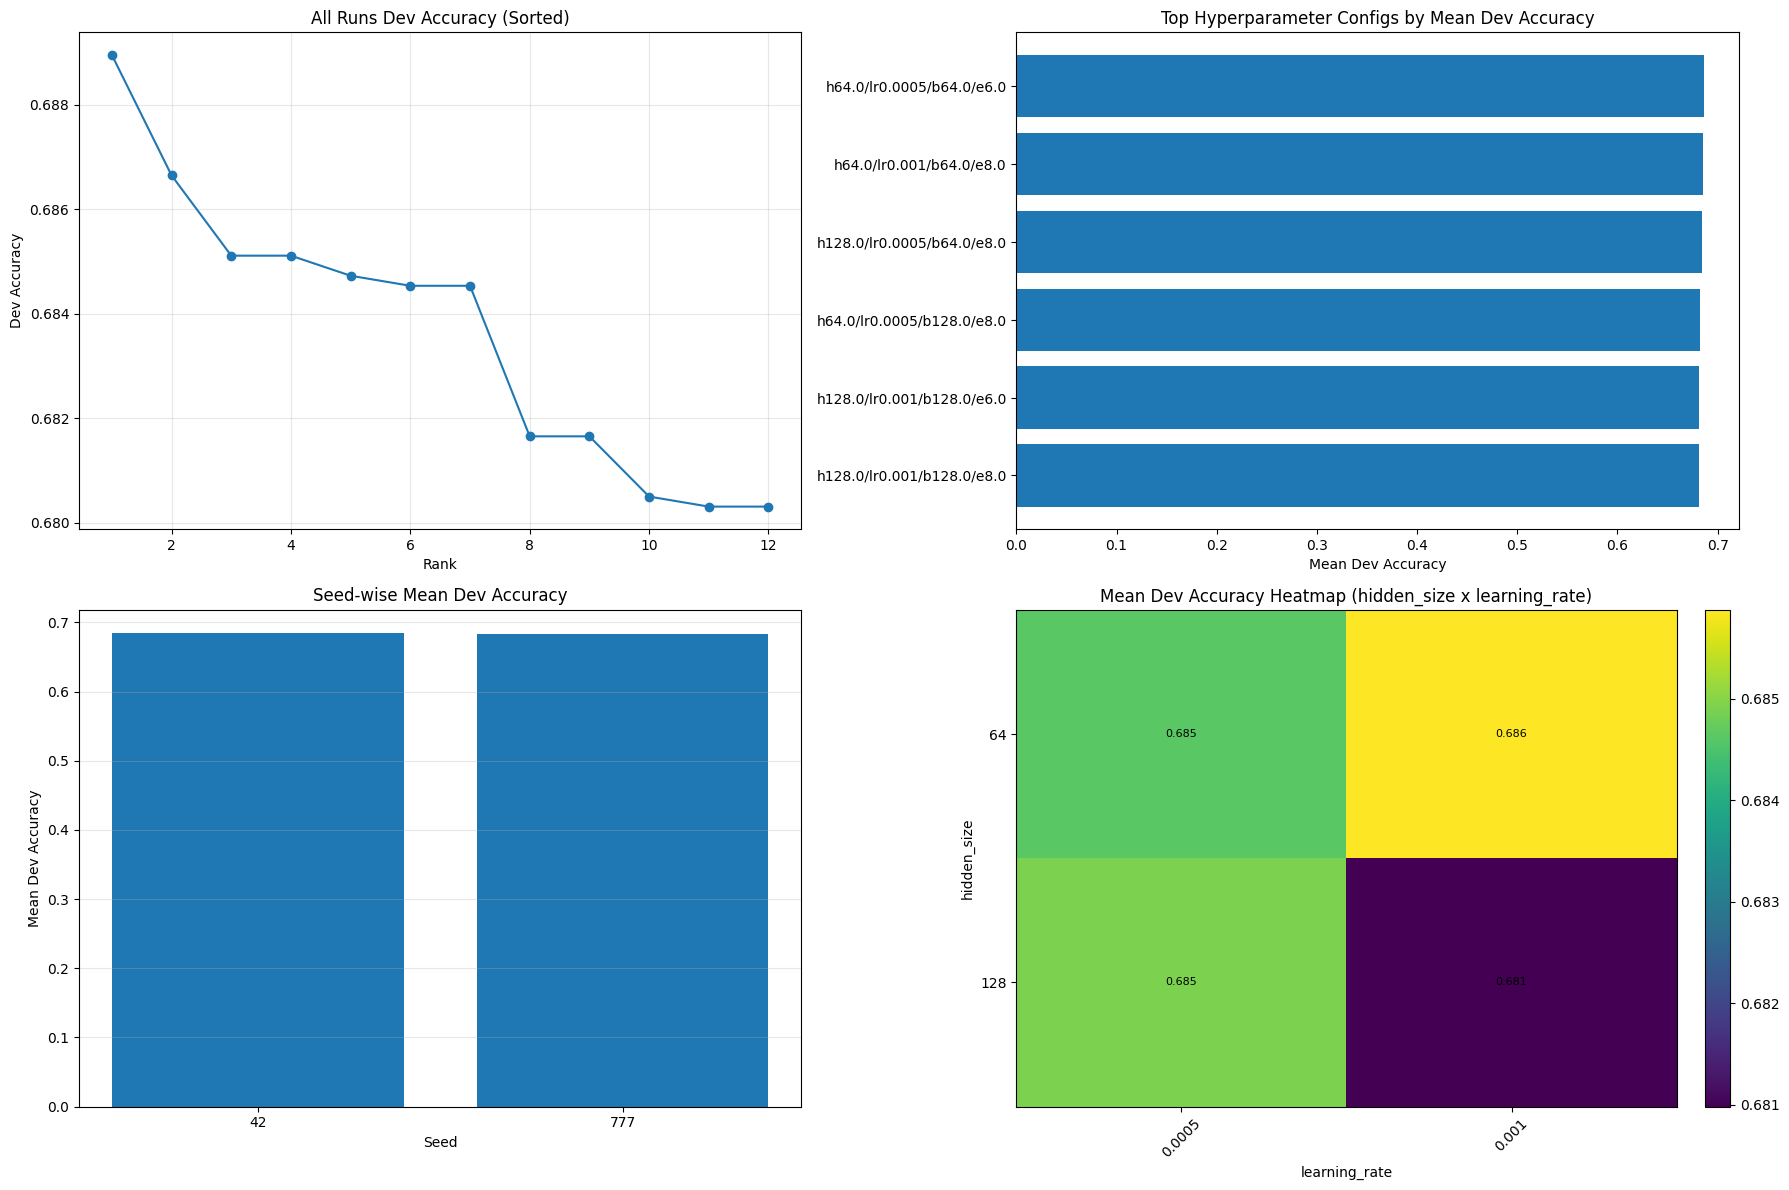


=== Seed Statistics ===


,seed,mean_dev_acc,max_dev_acc,min_dev_acc,std_dev_acc
0,42,0.683990,0.688953,0.680307,0.003282
1,777,0.683349,0.686647,0.680499,0.002419



=== Config Summary (Top 15 by mean_dev_acc) ===


,hidden_size,learning_rate,batch_size,num_epochs,mean_dev_acc,max_dev_acc,runs
0,64,0.0005,64,6,0.686743,0.688953,2
2,64,0.0010,64,8,0.685879,0.686647,2
3,128,0.0005,64,8,0.684918,0.685110,2
1,64,0.0005,128,8,0.682517,0.684534,2
4,128,0.0010,128,6,0.680980,0.681652,2
5,128,0.0010,128,8,0.680980,0.681652,2


In [16]:
# ===== TASK 7 결과 시각화: 모든 모델 성능 비교 =====
import pandas as pd
import matplotlib.pyplot as plt

if 'all_results' not in globals() or len(all_results) == 0:
    raise ValueError("먼저 TASK 7 학습 셀을 실행해서 all_results를 생성하세요.")

# 결과 테이블화
records = []
for i, r in enumerate(all_results, 1):
    records.append({
        "run_id": i,
        "dev_acc": r["dev_acc"],
        "hidden_size": r["config"]["hidden_size"],
        "learning_rate": r["config"]["learning_rate"],
        "batch_size": r["config"]["batch_size"],
        "num_epochs": r["config"]["num_epochs"],
        "seed": r["seed"],
        "config_key": f"h{r['config']['hidden_size']}_lr{r['config']['learning_rate']}_b{r['config']['batch_size']}_e{r['config']['num_epochs']}"
    })

results_df = pd.DataFrame(records).sort_values("dev_acc", ascending=False).reset_index(drop=True)

print("=== Top 10 Runs ===")
display(results_df.head(10))

# 그래프 레이아웃
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) 모든 run 성능 (내림차순)
sorted_scores = results_df["dev_acc"].sort_values(ascending=False).reset_index(drop=True)
axes[0, 0].plot(range(1, len(sorted_scores) + 1), sorted_scores.values, marker='o', linewidth=1.5)
axes[0, 0].set_title("All Runs Dev Accuracy (Sorted)")
axes[0, 0].set_xlabel("Rank")
axes[0, 0].set_ylabel("Dev Accuracy")
axes[0, 0].grid(alpha=0.3)

# 2) 하이퍼파라미터 조합별 평균/최고 성능
config_summary = (
    results_df
    .groupby(["hidden_size", "learning_rate", "batch_size", "num_epochs"], as_index=False)
    .agg(mean_dev_acc=("dev_acc", "mean"), max_dev_acc=("dev_acc", "max"), runs=("dev_acc", "count"))
    .sort_values("mean_dev_acc", ascending=False)
)

top_cfg = config_summary.head(12).copy()
top_cfg["label"] = top_cfg.apply(
    lambda x: f"h{x['hidden_size']}/lr{x['learning_rate']}/b{x['batch_size']}/e{x['num_epochs']}", axis=1
)

axes[0, 1].barh(top_cfg["label"], top_cfg["mean_dev_acc"])
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top Hyperparameter Configs by Mean Dev Accuracy")
axes[0, 1].set_xlabel("Mean Dev Accuracy")

# 3) seed별 성능 분포
seed_stats = results_df.groupby("seed", as_index=False).agg(
    mean_dev_acc=("dev_acc", "mean"),
    max_dev_acc=("dev_acc", "max"),
    min_dev_acc=("dev_acc", "min"),
    std_dev_acc=("dev_acc", "std")
).sort_values("mean_dev_acc", ascending=False)

axes[1, 0].bar(seed_stats["seed"].astype(str), seed_stats["mean_dev_acc"])
axes[1, 0].set_title("Seed-wise Mean Dev Accuracy")
axes[1, 0].set_xlabel("Seed")
axes[1, 0].set_ylabel("Mean Dev Accuracy")
axes[1, 0].grid(alpha=0.3, axis='y')

# 4) learning rate x hidden size 히트맵(평균 정확도)
heatmap_df = results_df.pivot_table(
    index="hidden_size", columns="learning_rate", values="dev_acc", aggfunc="mean"
).sort_index()

im = axes[1, 1].imshow(heatmap_df.values, aspect='auto')
axes[1, 1].set_title("Mean Dev Accuracy Heatmap (hidden_size x learning_rate)")
axes[1, 1].set_xlabel("learning_rate")
axes[1, 1].set_ylabel("hidden_size")
axes[1, 1].set_xticks(range(len(heatmap_df.columns)))
axes[1, 1].set_xticklabels([str(c) for c in heatmap_df.columns], rotation=45)
axes[1, 1].set_yticks(range(len(heatmap_df.index)))
axes[1, 1].set_yticklabels([str(i) for i in heatmap_df.index])

for y in range(heatmap_df.shape[0]):
    for x in range(heatmap_df.shape[1]):
        v = heatmap_df.values[y, x]
        axes[1, 1].text(x, y, f"{v:.3f}", ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n=== Seed Statistics ===")
display(seed_stats)

print("\n=== Config Summary (Top 15 by mean_dev_acc) ===")
display(config_summary.head(15))

## TASK 7 BOOST - Same MLP, Hyperparameter Tuning Only

In [18]:
# 기존 MLP 아키텍처 고정 + 하이퍼파라미터 튜닝 + 시드 앙상블
# 모델 구조는 MLP 클래스를 그대로 사용하고, 학습 설정만 최적화

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from sklearn.metrics import accuracy_score


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    cudnn.benchmark = False
    cudnn.deterministic = True


# 데이터 준비 (CPU에 두고 배치만 GPU 전송)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_cpu = torch.tensor(train_vectors.toarray(), dtype=torch.float32)
y_train_cpu = torch.tensor(train_data['label'], dtype=torch.long)
X_dev_cpu = torch.tensor(dev_vectors.toarray(), dtype=torch.float32)
y_dev_cpu = torch.tensor(dev_data['label'], dtype=torch.long)
X_test_cpu = torch.tensor(test_vectors.toarray(), dtype=torch.float32)
y_test_cpu = torch.tensor(test_data['label'], dtype=torch.long)

input_size = X_train_cpu.shape[1]
output_size = 3


def predict_probs_batched(model, X_cpu, infer_batch_size=1024):
    model.eval()
    probs_all = []
    with torch.no_grad():
        for i in range(0, len(X_cpu), infer_batch_size):
            xb = X_cpu[i:i + infer_batch_size].to(device, non_blocking=True)
            logits = model(xb)
            probs_all.append(torch.softmax(logits, dim=1).detach().cpu())
    return torch.cat(probs_all, dim=0)


# -------- 탐색 공간 (아키텍처 동일, 학습 파라미터만 변경) --------
search_space = {
    "hidden_size": [64, 96, 128, 192, 256],
    "learning_rate": [3e-4, 5e-4, 8e-4, 1e-3, 2e-3],
    "batch_size": [32, 64, 128],
    "weight_decay": [0.0, 1e-5, 1e-4, 5e-4],
    "num_epochs": [12, 16, 20]
}

seed_list = [42, 777, 2024]
max_trials = 14
patience = 3
infer_batch_size = 1024

# 조합 전체에서 일부 랜덤 샘플링
all_configs = [
    {
        "hidden_size": hs,
        "learning_rate": lr,
        "batch_size": bs,
        "weight_decay": wd,
        "num_epochs": ne
    }
    for hs, lr, bs, wd, ne in product(
        search_space["hidden_size"],
        search_space["learning_rate"],
        search_space["batch_size"],
        search_space["weight_decay"],
        search_space["num_epochs"]
    )
]
random.seed(42)
selected_configs = random.sample(all_configs, k=min(max_trials, len(all_configs)))


def train_and_eval(config, seed):
    set_global_seed(seed)

    model = MLP(input_size, config["hidden_size"], output_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )

    best_dev_acc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(config["num_epochs"]):
        model.train()

        idx = torch.randperm(len(X_train_cpu))
        for i in range(0, len(idx), config["batch_size"]):
            bidx = idx[i:i + config["batch_size"]]
            xb = X_train_cpu[bidx].to(device, non_blocking=True)
            yb = y_train_cpu[bidx].to(device, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        dev_probs = predict_probs_batched(model, X_dev_cpu, infer_batch_size)
        dev_pred = torch.argmax(dev_probs, dim=1)
        dev_acc = (dev_pred == y_dev_cpu).float().mean().item()

        scheduler.step(dev_acc)

        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    final_dev_probs = predict_probs_batched(model, X_dev_cpu, infer_batch_size)
    final_dev_pred = torch.argmax(final_dev_probs, dim=1)
    final_dev_acc = (final_dev_pred == y_dev_cpu).float().mean().item()

    result = {
        "state_dict": copy.deepcopy(model.state_dict()),
        "dev_acc": final_dev_acc,
        "config": config,
        "seed": seed,
        "dev_probs": final_dev_probs
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# -------- 탐색 실행 --------
all_results_mlp_boost = []
run_id = 0
total_runs = len(selected_configs) * len(seed_list)
print(f"Total runs (MLP boost): {total_runs}")

for config in selected_configs:
    for seed in seed_list:
        run_id += 1
        r = train_and_eval(config, seed)
        all_results_mlp_boost.append(r)
        print(
            f"[{run_id:03d}/{total_runs}] dev_acc={r['dev_acc']:.4f} "
            f"config={config} seed={seed}"
        )

# -------- 단일 최고 성능 --------
all_results_mlp_boost = sorted(all_results_mlp_boost, key=lambda x: x["dev_acc"], reverse=True)
best_single = all_results_mlp_boost[0]
print("\n[MLP BOOST Best Single]")
print(f"dev_acc={best_single['dev_acc']:.4f}, config={best_single['config']}, seed={best_single['seed']}")

# -------- 상위 모델 소프트보팅 앙상블 --------
max_k = min(5, len(all_results_mlp_boost))
best_ens_acc = -1.0
best_ens_k = 1
best_ens_members = None

for k in range(2, max_k + 1):
    members = all_results_mlp_boost[:k]
    ens_dev_prob = torch.stack([m["dev_probs"] for m in members], dim=0).mean(dim=0)
    ens_dev_pred = torch.argmax(ens_dev_prob, dim=1)
    ens_dev_acc = accuracy_score(y_dev_cpu.numpy(), ens_dev_pred.numpy())

    if ens_dev_acc > best_ens_acc:
        best_ens_acc = ens_dev_acc
        best_ens_k = k
        best_ens_members = members

print("[MLP BOOST Best Ensemble]")
if best_ens_members is not None:
    print(f"top_k={best_ens_k}, dev_acc={best_ens_acc:.4f}")
else:
    print("single model 사용")

# -------- 최종 선택 --------
use_ensemble = best_ens_members is not None and best_ens_acc >= best_single["dev_acc"]
if use_ensemble:
    final_mode = f"ensemble_top_{best_ens_k}"
    final_dev_acc_mlp_boost = best_ens_acc
else:
    final_mode = "single_best"
    final_dev_acc_mlp_boost = best_single["dev_acc"]

print(f"\n[MLP BOOST Final Selection] {final_mode}, dev_acc={final_dev_acc_mlp_boost:.4f}")

# -------- 테스트 평가 --------
if use_ensemble:
    member_probs = []
    with torch.no_grad():
        for m in best_ens_members:
            mdl = MLP(input_size, m["config"]["hidden_size"], output_size).to(device)
            mdl.load_state_dict(m["state_dict"])
            probs = predict_probs_batched(mdl, X_test_cpu, infer_batch_size)
            member_probs.append(probs)
            del mdl

    test_prob = torch.stack(member_probs, dim=0).mean(dim=0)
    test_pred = torch.argmax(test_prob, dim=1).numpy()
else:
    mdl = MLP(input_size, best_single["config"]["hidden_size"], output_size).to(device)
    mdl.load_state_dict(best_single["state_dict"])
    test_prob = predict_probs_batched(mdl, X_test_cpu, infer_batch_size)
    test_pred = torch.argmax(test_prob, dim=1).numpy()
    del mdl

final_test_acc_mlp_boost = accuracy_score(y_test_cpu.numpy(), test_pred)
print(f"MLP BOOST Final Test Accuracy: {final_test_acc_mlp_boost * 100:.2f}%")

# -------- 결과 요약/시각화 --------
records = []
for i, r in enumerate(all_results_mlp_boost, 1):
    cfg = r['config']
    records.append({
        'rank': i,
        'dev_acc': r['dev_acc'],
        'hidden_size': cfg['hidden_size'],
        'learning_rate': cfg['learning_rate'],
        'batch_size': cfg['batch_size'],
        'weight_decay': cfg['weight_decay'],
        'num_epochs': cfg['num_epochs'],
        'seed': r['seed']
    })

mlp_boost_df = pd.DataFrame(records)
print("\n=== MLP BOOST Top 10 ===")
display(mlp_boost_df.head(10))

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(mlp_boost_df) + 1), mlp_boost_df['dev_acc'].values, marker='o')
plt.title('MLP BOOST Dev Accuracy by Rank')
plt.xlabel('Rank')
plt.ylabel('Dev Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 기존 결과와 비교(있으면)
compare_rows = [
    {'model': 'MLP BOOST (same architecture)', 'test_acc': final_test_acc_mlp_boost}
]
if 'final_test_acc' in globals():
    compare_rows.append({'model': 'Previous TASK7 fast', 'test_acc': final_test_acc})
if 'boost_test_acc' in globals():
    compare_rows.append({'model': 'TF-IDF BOOST', 'test_acc': boost_test_acc})

compare_df = pd.DataFrame(compare_rows).sort_values('test_acc', ascending=False).reset_index(drop=True)
print("\n=== Test Accuracy Comparison ===")
display(compare_df)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total runs (MLP boost): 42
[001/42] dev_acc=0.6913 config={'hidden_size': 192, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=42
[002/42] dev_acc=0.6893 config={'hidden_size': 192, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=777
[003/42] dev_acc=0.6830 config={'hidden_size': 192, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=2024
[004/42] dev_acc=0.6872 config={'hidden_size': 64, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=42
[005/42] dev_acc=0.6874 config={'hidden_size': 64, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=777
[006/42] dev_acc=0.6905 config={'hidden_size': 64, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'num_epochs': 12} seed=2024
[007/42] dev_acc=0.6840 config={'hidden_size': 64, 'learning_rate': 0.0003, 'batch_size': 128, 'weight_dec

KeyboardInterrupt: 

## TASK 8 BOOST - High Performance (TF-IDF + Ensemble)

C=2.0, seed=42, dev_acc=0.6982
C=2.0, seed=777, dev_acc=0.6982
C=2.0, seed=2024, dev_acc=0.6982
C=4.0, seed=42, dev_acc=0.6955
C=4.0, seed=777, dev_acc=0.6955
C=4.0, seed=2024, dev_acc=0.6955
C=8.0, seed=42, dev_acc=0.6891
C=8.0, seed=777, dev_acc=0.6891
C=8.0, seed=2024, dev_acc=0.6891

[BOOST Best Single]
dev_acc=0.6982, C=2.0, seed=42
[BOOST Ensemble]
top_k=4, dev_acc=0.6976

[BOOST Final] mode=Single best, test_acc=69.72%

=== Classification Report (BOOST on test) ===
              precision    recall  f1-score   support

           0     0.6977    0.6986    0.6981      1546
           1     0.6364    0.6423    0.6393      1929
           2     0.7661    0.7572    0.7616      1730

    accuracy                         0.6972      5205
   macro avg     0.7000    0.6994    0.6997      5205
weighted avg     0.6977    0.6972    0.6974      5205



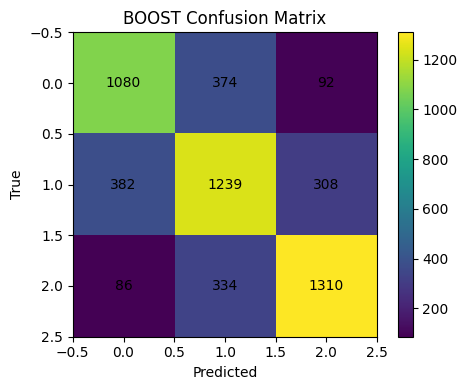


=== Test Accuracy Comparison ===


,model,test_acc
0,BOOST (TF-IDF ensemble),0.697214
1,Previous TASK7 model,0.685303


In [17]:
# 고성능 텍스트 분류기: word + char TF-IDF + Logistic Regression 앙상블
# 이 방식은 BoW+MLP보다 감성분류에서 더 강한 경우가 많음

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train_text = train_data['text']
X_dev_text = dev_data['text']
X_test_text = test_data['text']

y_train = np.array(train_data['label'])
y_dev = np.array(dev_data['label'])
y_test = np.array(test_data['label'])

# 1) Word n-gram TF-IDF
word_vec = TfidfVectorizer(
    lowercase=True,
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_features=120000,
    sublinear_tf=True
)

# 2) Character n-gram TF-IDF
char_vec = TfidfVectorizer(
    lowercase=True,
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2,
    max_features=80000,
    sublinear_tf=True
)

Xtr_w = word_vec.fit_transform(X_train_text)
Xdv_w = word_vec.transform(X_dev_text)
Xte_w = word_vec.transform(X_test_text)

Xtr_c = char_vec.fit_transform(X_train_text)
Xdv_c = char_vec.transform(X_dev_text)
Xte_c = char_vec.transform(X_test_text)

# seed 앙상블 + C 튜닝 (가벼운 범위)
seeds = [42, 777, 2024]
c_values = [2.0, 4.0, 8.0]

runs = []
for C in c_values:
    for sd in seeds:
        clf_w = LogisticRegression(
            C=C,
            max_iter=2500,
            solver='liblinear',
            class_weight='balanced',
            random_state=sd
        )
        clf_c = LogisticRegression(
            C=C,
            max_iter=2500,
            solver='liblinear',
            class_weight='balanced',
            random_state=sd
        )

        clf_w.fit(Xtr_w, y_train)
        clf_c.fit(Xtr_c, y_train)

        # word/char soft voting
        dev_prob = 0.55 * clf_w.predict_proba(Xdv_w) + 0.45 * clf_c.predict_proba(Xdv_c)
        dev_pred = np.argmax(dev_prob, axis=1)
        dev_acc = accuracy_score(y_dev, dev_pred)

        runs.append({
            'C': C,
            'seed': sd,
            'dev_acc': dev_acc,
            'clf_w': clf_w,
            'clf_c': clf_c
        })
        print(f"C={C}, seed={sd}, dev_acc={dev_acc:.4f}")

# dev 상위 모델 앙상블
runs = sorted(runs, key=lambda x: x['dev_acc'], reverse=True)
top_k = 4
top_runs = runs[:top_k]

ensemble_dev_prob = np.mean(
    [0.55 * r['clf_w'].predict_proba(Xdv_w) + 0.45 * r['clf_c'].predict_proba(Xdv_c) for r in top_runs],
    axis=0
)
ensemble_dev_pred = np.argmax(ensemble_dev_prob, axis=1)
ensemble_dev_acc = accuracy_score(y_dev, ensemble_dev_pred)

best_single = runs[0]
best_single_dev_acc = best_single['dev_acc']

print("\n[BOOST Best Single]")
print(f"dev_acc={best_single_dev_acc:.4f}, C={best_single['C']}, seed={best_single['seed']}")
print("[BOOST Ensemble]")
print(f"top_k={top_k}, dev_acc={ensemble_dev_acc:.4f}")

use_ensemble_boost = ensemble_dev_acc >= best_single_dev_acc

if use_ensemble_boost:
    # test 앙상블
    ensemble_test_prob = np.mean(
        [0.55 * r['clf_w'].predict_proba(Xte_w) + 0.45 * r['clf_c'].predict_proba(Xte_c) for r in top_runs],
        axis=0
    )
    final_test_pred_boost = np.argmax(ensemble_test_prob, axis=1)
    boost_mode = f"Ensemble top-{top_k}"
else:
    single_test_prob = 0.55 * best_single['clf_w'].predict_proba(Xte_w) + 0.45 * best_single['clf_c'].predict_proba(Xte_c)
    final_test_pred_boost = np.argmax(single_test_prob, axis=1)
    boost_mode = "Single best"

boost_test_acc = accuracy_score(y_test, final_test_pred_boost)
print(f"\n[BOOST Final] mode={boost_mode}, test_acc={boost_test_acc*100:.2f}%")

# 상세 리포트
print("\n=== Classification Report (BOOST on test) ===")
print(classification_report(y_test, final_test_pred_boost, digits=4))

# 혼동행렬 시각화
cm = confusion_matrix(y_test, final_test_pred_boost)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('BOOST Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()

# 기존 모델 대비 비교(있으면)
compare_rows = [{
    'model': 'BOOST (TF-IDF ensemble)',
    'test_acc': boost_test_acc
}]

if 'final_test_acc' in globals():
    compare_rows.append({'model': 'Previous TASK7 model', 'test_acc': final_test_acc})

compare_df = pd.DataFrame(compare_rows).sort_values('test_acc', ascending=False).reset_index(drop=True)
print("\n=== Test Accuracy Comparison ===")
display(compare_df)